# <center>Credit Scoring Model</center>

In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, k_means
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import norm
plt.rcParams["figure.figsize"] = (16, 9)

## Data

In [40]:
#pd.read_fwf("http://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric", header = None)

https://www.kaggle.com/datasets/conorsully1/credit-score

In [9]:
path = kagglehub.dataset_download("conorsully1/credit-score")

In [13]:
data_raw = pd.read_csv(path + "/credit_score.csv")

In [41]:
#data_raw.dtypes[60:]

In [34]:
df = data_raw.iloc[:, 1:].drop(columns = 'CAT_GAMBLING')

In [68]:
df['NO_GAMBLING'] = (data_raw['CAT_GAMBLING'] == 'No') * 1
df['HIGH_GAMBLING'] = (data_raw['CAT_GAMBLING'] == 'High') * 1

In [162]:
#(df.corr() * (df.corr() != 1)).max()
#df.corr()['DEFAULT'][:60]
#for i in df.columns:
#    if (df[i].dtype == 'int64') & (~df[i].isin([0, 1]).all()):
#        print((df[i] == 0).sum() / 1000)

##### Standardization

In [73]:
df_st = pd.DataFrame()
for i in df.columns:
    if (~df[i].isin([0, 1]).all()):
        df_st[i] = (df[i] - df[i].mean()) / df[i].std()
    else:
        df_st[i] = df[i]

##### Train-test split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(df_st.drop(columns = 'DEFAULT'), df_st['DEFAULT'], train_size = 0.8)

## EDA

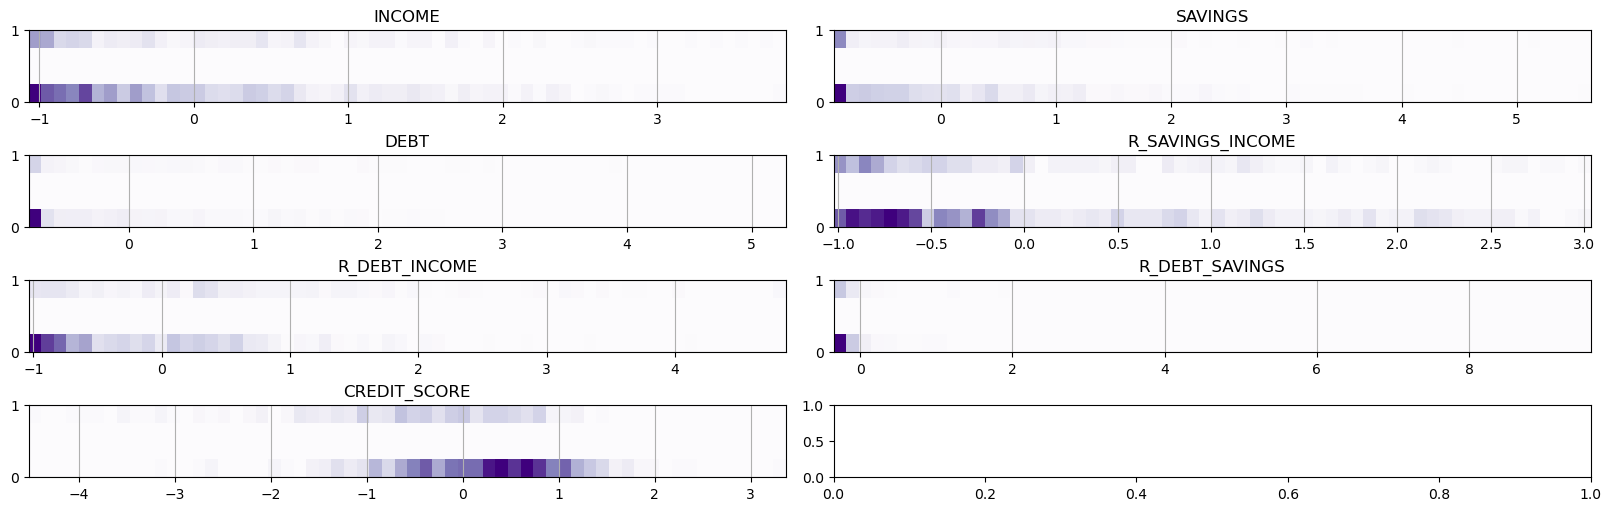

In [187]:
fig, ax = plt.subplots(4, 2, figsize = (16, 5), constrained_layout = True)
for i, var in enumerate(['INCOME', 'SAVINGS', 'DEBT', 'R_SAVINGS_INCOME', 'R_DEBT_INCOME', 'R_DEBT_SAVINGS', 'CREDIT_SCORE']):
    #ax[i // 2, i % 2].scatter(X_train[var], y_train, s = 5)
    ax[i // 2, i % 2].hist2d(X_train[var], y_train, bins = (60, 4), cmap = 'Purples')
    ax[i // 2, i % 2].set_yticks([0, 1])
    ax[i // 2, i % 2].set_title(var)
    ax[i // 2, i % 2].grid()
plt.show()

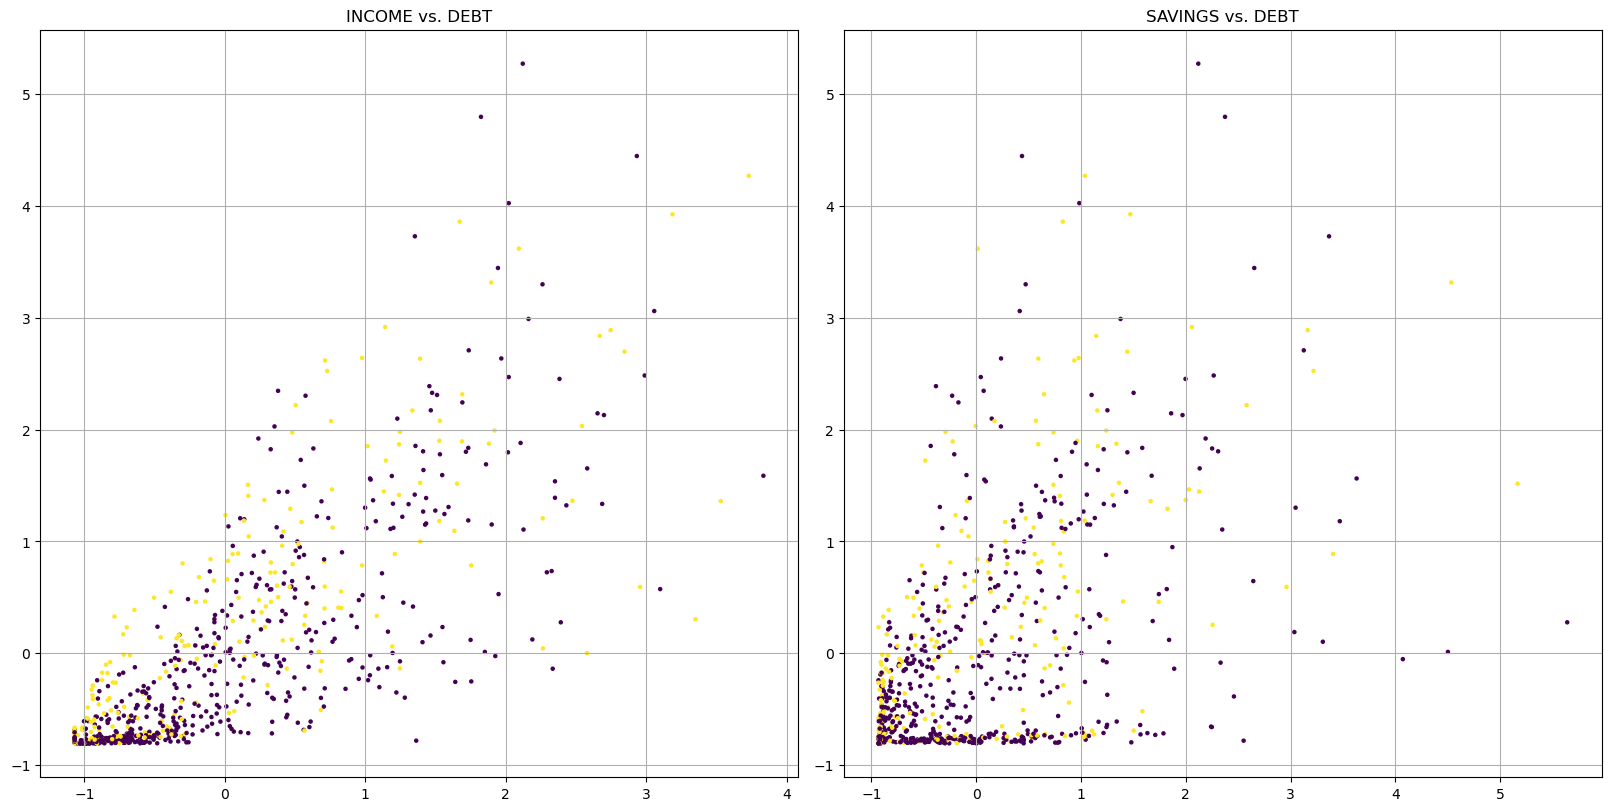

In [192]:
fig, ax = plt.subplots(1, 2, figsize = (16, 8), constrained_layout = True)
for i, (var1, var2) in enumerate([('INCOME', 'DEBT'), ('SAVINGS', 'DEBT')]):
    ax[i].scatter(X_train[var1], X_train[var2], c = y_train, s = 5)
    #ax[i].set_yticks([0, 1])
    ax[i].set_title(var1 + ' vs. ' + var2)
    ax[i].grid()
plt.show()

In [163]:
n = len(X_train)
#n_sig = 0
cont_vars = (~X_train.isin([0, 1]).all()[~X_train.isin([0, 1]).all()]).index
for i in cont_vars:
    rho = X_train[i].corr(y_train)
    p = 2 - 2 * norm.cdf(abs(rho / np.sqrt(1 - rho ** 2) * np.sqrt(n - 2)))
    rho2 = (X_train[i] ** 2).corr(y_train)
    p2 = 2 - 2 * norm.cdf(abs(rho2 / np.sqrt(1 - rho2 ** 2) * np.sqrt(n - 2)))
    if (p > 0.05) & (p2 < 0.05):
        print(i, rho2, p2)
    #print(i, rho, p)
    #if p < 0.05:
    #    n_sig += 1

T_CLOTHING_12 0.07939876813416755 0.024446986223544798
T_ENTERTAINMENT_12 0.0966837604027927 0.006068355665768799
T_ENTERTAINMENT_6 0.0927394182388951 0.008510271950108228
R_GAMBLING_INCOME -0.0741845825226809 0.0356038678276589
T_UTILITIES_12 0.07703289701083979 0.029066787279447448
T_UTILITIES_6 0.07770452134238862 0.02768482236895231


In [165]:
for i in cont_vars:
    x2 = X_train[i] ** 2
    n_y1 = y_train.sum()
    x2_m1 = (x2 * y_train).sum() / n_y1
    x2_m0 = (x2 * (1 - y_train)).sum() / (n - n_y1)
    t_stat = (x2_m1 - x2_m0) / np.sqrt((((x2 * y_train) ** 2).sum() + ((x2 * (1 - y_train)) ** 2).sum()) / (n - 2) * (1 / n_y1 + 1 / (n - n_y1)))
    print(i, t_stat)

INCOME 1.5407537131053781
SAVINGS 0.7102490709578362
DEBT 1.5602273417357393
R_SAVINGS_INCOME -0.9611196714336699
R_DEBT_INCOME 5.483728321694717
R_DEBT_SAVINGS 1.6350932866822039
T_CLOTHING_12 2.064775357355468
T_CLOTHING_6 1.3049052704850064
R_CLOTHING -0.3095443876105095
R_CLOTHING_INCOME -0.06423005653019333
R_CLOTHING_SAVINGS 1.557962586304924
R_CLOTHING_DEBT -1.4733979941266202
T_EDUCATION_12 0.05083477920409498
T_EDUCATION_6 0.047376321861645476
R_EDUCATION -0.3914848888934052
R_EDUCATION_INCOME 2.1100053170554975
R_EDUCATION_SAVINGS 2.0716531221279113
R_EDUCATION_DEBT -0.6217107766314379
T_ENTERTAINMENT_12 2.2925710959023133
T_ENTERTAINMENT_6 2.3546306807097426
R_ENTERTAINMENT 1.2699411309613833
R_ENTERTAINMENT_INCOME -1.1478854579995716
R_ENTERTAINMENT_SAVINGS 0.7131921239219593
R_ENTERTAINMENT_DEBT -1.9291521016988888
T_FINES_12 1.1222297482656187
T_FINES_6 2.3025699702105995
R_FINES -0.7386702479493943
R_FINES_INCOME -0.16553114531842114
R_FINES_SAVINGS 0.947846493959107
R_F

In [160]:
prods = pd.DataFrame(columns = ['var1', 'var2', 'rho', 'p'])
for i in df_st.drop(columns = 'DEFAULT').columns:
    for j in df_st.drop(columns = 'DEFAULT').columns:
        if (i != j) & (j not in list(prods['var1'])):
            prod_ij = df_st[i] * df_st[j]
            if ~(prod_ij == 0).all():
                rho = prod_ij.corr(df_st['DEFAULT'])
                p = 2 - 2 * norm.cdf(abs(rho / np.sqrt(1 - rho ** 2) * np.sqrt(n - 2)))
                prods = pd.concat([prods, pd.DataFrame({'var1': [i], 'var2': [j], 'rho': [rho], 'p': [p]})])

C:\Users\wojci\AppData\Local\Temp\ipykernel_35476\1470713527.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  prods = pd.concat([prods, pd.DataFrame({'var1': [i], 'var2': [j], 'rho': [rho], 'p': [p]})])


In [158]:
(prods['p'] < 0.001).sum()

200

### Model Estimation and Performance Testing

In [76]:
def performance(y_real, y_predicted):
    print('The confusion matrix is:')
    print(confusion_matrix(y_real, y_predicted))
    metrics = {'Accuracy': accuracy_score, 'Precision': precision_score, 'Recall': recall_score, 'F1': f1_score}
    for metrics, func in metrics.items():
        print(metrics+': %.2f'%(func(y_real, y_predicted)))

#### Scikit-learn Logistic Regression

In [79]:
skl_LR = LogisticRegression(max_iter = 1000, penalty = None, tol = 10e-6)
skl_LR.fit(X_train, y_train)

LogisticRegression(max_iter=1000, penalty=None, tol=1e-05)

In [141]:
prob_thr = y_train.mean()

In [142]:
y_tr_pr = (skl_LR.predict_proba(X_train)[:, 1] > prob_thr) * 1
performance(y_train, y_tr_pr)

The confusion matrix is:
[[416 148]
 [ 64 172]]
Accuracy: 0.73
Precision: 0.54
Recall: 0.73
F1: 0.62


In [143]:
y_te_pr = (skl_LR.predict_proba(X_test)[:, 1] > prob_thr) * 1
performance(y_test, y_te_pr)

The confusion matrix is:
[[109  43]
 [ 30  18]]
Accuracy: 0.64
Precision: 0.30
Recall: 0.38
F1: 0.33


#### Statsmodels Logistic Regression

In [196]:
sm_LR = sm.GLM(y_train, X_train, family = sm.families.Binomial()).fit()
sm_LR.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                DEFAULT   No. Observations:                  800
Model:                            GLM   Df Residuals:                      716
Model Family:                Binomial   Df Model:                           83
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -374.87
Date:                Thu, 03 Sep 2026   Deviance:                       749.73
Time:                        03:20:15   Pearson chi2:                     771.
No. Iterations:                   100   Pseudo R-squ. (CS):             0.2412
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
INCOME                      0.3580      0.962      0.372      0.710      -1.527       2.243
SAVINGS                    -0.4013      0.248     -1.619      0.106      -0.887       0.085
DEBT                       -0.7880      0.272     -2.896      0.004      -1.321      -0.255
R_SAVINGS_INCOME            0.5818      0.264      2.202      0.028       0.064       1.100
R_DEBT_INCOME               0.2265      0.332      0.683      0.494      -0.423       0.876
R_DEBT_SAVINGS             -0.3621      0.305     -1.185      0.236      -0.961       0.237
T_CLOTHING_12             -28.8514     37.115     -0.777      0.437    -101.596      43.893
T_CLOTHING_6               31.3011     40.154      0.780      0.436     -47.398     110.001
R_CLOTHING                 -0.2013      0.158     -1.272      0.203      -0.511       0.109
R_CLOTHING_INCOME           0.1143      0.271      0.422      0.673      -0.417       0.646
R_CLOTHING_SAVINGS          0.5221      0.439      1.189      0.235      -0.339       1.383
R_CLOTHING_DEBT             0.1160      0.415      0.280      0.780      -0.697       0.928
T_EDUCATION_12            -32.3853     46.110     -0.702      0.482    -122.760      57.989
T_EDUCATION_6              26.8103     40.985      0.654      0.513     -53.519     107.139
R_EDUCATION                -0.1258      0.111     -1.139      0.255      -0.342       0.091
R_EDUCATION_INCOME         -0.2191      0.241     -0.909      0.363      -0.692       0.253
R_EDUCATION_SAVINGS         0.9275      0.440      2.109      0.035       0.065       1.790
R_EDUCATION_DEBT            0.1231      0.394      0.313      0.755      -0.649       0.895
T_ENTERTAINMENT_12        -48.6784     61.453     -0.792      0.428    -169.124      71.767
T_ENTERTAINMENT_6          45.8574     57.893      0.792      0.428     -67.612     159.327
R_ENTERTAINMENT            -0.0724      0.167     -0.434      0.665      -0.400       0.255
R_ENTERTAINMENT_INCOME     -0.4054      0.315     -1.286      0.198      -1.023       0.212
R_ENTERTAINMENT_SAVINGS     2.1882      1.020      2.144      0.032       0.188       4.188
R_ENTERTAINMENT_DEBT       -0.1469      0.555     -0.265      0.791      -1.235       0.941
T_FINES_12                 -0.5042      0.711     -0.710      0.478      -1.897       0.888
T_FINES_6                   0.9470      0.720      1.316      0.188      -0.464       2.358
R_FINES                     0.0203      0.100      0.202      0.840      -0.176       0.217
R_FINES_INCOME             -1.3460      0.463     -2.904      0.004      -2.254      -0.438
R_FINES_SAVINGS             1.1000      0.419      2.623      0.009       0.278       1.922
R_FINES_DEBT                0.6166      0.468      1.316      0.188      -0.301       1.535
T_GAMBLING_12             -19.0868     24.926  

In [204]:
performance(y_train, (sm_LR.predict() > prob_thr) * 1)

The confusion matrix is:
[[410 154]
 [ 60 176]]
Accuracy: 0.73
Precision: 0.53
Recall: 0.75
F1: 0.62


In [205]:
performance(y_test, (sm_LR.predict(exog = X_test) > prob_thr) * 1)

The confusion matrix is:
[[107  45]
 [ 30  18]]
Accuracy: 0.62
Precision: 0.29
Recall: 0.38
F1: 0.32
